<a href="https://colab.research.google.com/github/prathamkumar101/Deepfake-Image-Detection-/blob/main/Efficientnet_Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

# 1. Upload kaggle.json file
print("Upload your kaggle.json file:")
files.upload()

# 2. Set up the Kaggle directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the DeepDetect-2025 dataset
# The -d flag specifies the dataset slug from your screenshot
print("Downloading dataset...")
!kaggle datasets download -d ayushmandatta1/deepdetect-2025

# 4. Unzip the dataset
print("Unzipping...")
!unzip -q deepdetect-2025.zip -d deepdetect_dataset

print("Done! Data is ready in the 'deepdetect_dataset' folder.")

Upload your kaggle.json file:


Saving kaggle .json to kaggle .json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
Unzipping...
unzip:  cannot find or open deepdetect-2025.zip, deepdetect-2025.zip.zip or deepdetect-2025.zip.ZIP.
Done! 

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Define the base directory where you unzipped the data
base_dir = 'deepdetect_dataset'

# 1. Check what's inside the folder to find the actual data path
print(f"Contents of '{base_dir}':")
print(os.listdir(base_dir))

# Note: Sometimes Kaggle datasets unzip into a nested subfolder.
# We need to find where 'train' and 'test' folders are.
# Let's assume a common structure and look for it:

def find_image_dirs(start_path):
    for root, dirs, files in os.walk(start_path):
        if 'train' in dirs and 'test' in dirs:
            return os.path.join(root, 'train'), os.path.join(root, 'test')
    return None, None

train_dir, test_dir = find_image_dirs(base_dir)

if train_dir:
    print(f"\nFound training data at: {train_dir}")
    classes = os.listdir(train_dir)
    print(f"Classes found: {classes}")

    # 2. Visualize one random image from each class
    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(classes):
        class_path = os.path.join(train_dir, class_name)
        if os.path.isdir(class_path): # Ensure it's a folder
            images = os.listdir(class_path)
            if images:
                # Pick a random image
                img_name = random.choice(images)
                img_path = os.path.join(class_path, img_name)

                # Display
                img = mpimg.imread(img_path)
                plt.subplot(1, len(classes), i+1)
                plt.imshow(img)
                plt.title(f"{class_name}\n({len(images)} images)")
                plt.axis('off')
    plt.show()
else:
    print("\nCould not automatically find 'train' and 'test' folders. Please check the print output above to see the structure.")

Contents of 'deepdetect_dataset':


FileNotFoundError: [Errno 2] No such file or directory: 'deepdetect_dataset'

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# --- Configuration ---
BATCH_SIZE = 32
IMG_SIZE = 224
RANDOM_SEED = 42

# --- Path Setup ---
# Based on your screenshot, the training data is inside 'ddata/train'
DATA_DIR = os.path.join('deepdetect_dataset', 'ddata', 'train')

# --- Transforms ---
# Standard normalization for pre-trained models
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load and Split Data ---
if os.path.exists(DATA_DIR):
    full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

    # 80/20 Train/Val Split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # Data Loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Data Loaded Successfully:")
    print(f"- Training Samples: {len(train_dataset)}")
    print(f"- Validation Samples: {len(val_dataset)}")
    print(f"- Classes: {full_dataset.classes}")
else:
    print(f"Error: Could not find dataset at {DATA_DIR}. Please check the folder name.")

Error: Could not find dataset at deepdetect_dataset/ddata/train. Please check the folder name.


In [ ]:
from torchvision import models
import torch.nn as nn

# 1. Download Pre-trained EfficientNet-B0
# Weights='DEFAULT' downloads the best available pre-trained weights
model = models.efficientnet_b0(weights='DEFAULT')

# 2. Freeze Early Layers (Optional but recommended)
# This prevents destroying the pre-learned features during the first epoch
for param in model.features.parameters():
    param.requires_grad = False

# 3. Modify the Classifier Head
# EfficientNet's original classifier outputs 1000 classes. We change it to 1.
num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 1)  # Output 1 value: Probability of being 'Fake'
)

# 4. Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model initialized on device: {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 204MB/s]


Model initialized on device: cuda


In [ ]:
import torch.optim as optim
import time
import copy
import torch.nn as nn
# Model Training UP-TO 1-10 EPOCHS
# --- Hyperparameters ---
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

# --- Loss Function & Optimizer ---
# BCEWithLogitsLoss includes a Sigmoid layer, providing more numerical stability
criterion = nn.BCEWithLogitsLoss()

# Adam is chosen for its adaptive learning rate capabilities
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Decay LR by a factor of 0.1 every 4 epochs to fine-tune convergence
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # Apply sigmoid to get probabilities, then threshold at 0.5
                    preds = torch.sigmoid(outputs) > 0.5

                    # Backward pass + optimize only in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Record history
            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

            # Deep copy the model if it's the best one seen so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # Save the checkpoint locally
                torch.save(model.state_dict(), 'best_deepfake_model.pth')
                print("-> Best model updated and saved.")

        print() # Empty line for readability between epochs

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_acc:.4f}')

    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accs, val_accs

# --- Execute Training ---
print(f"Starting training for {NUM_EPOCHS} epochs...")
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS
)

Starting training for 10 epochs...
Epoch 1/10
----------
train Loss: 0.4766 Acc: 0.7738
val Loss: 0.4036 Acc: 0.8202
-> Best model updated and saved.

Epoch 2/10
----------
train Loss: 0.4497 Acc: 0.7899
val Loss: 0.3947 Acc: 0.8242
-> Best model updated and saved.

Epoch 3/10
----------
train Loss: 0.4490 Acc: 0.7913
val Loss: 0.3966 Acc: 0.8239

Epoch 4/10
----------
train Loss: 0.4484 Acc: 0.7901
val Loss: 0.3986 Acc: 0.8212

Epoch 5/10
----------
train Loss: 0.4425 Acc: 0.7951
val Loss: 0.3839 Acc: 0.8307
-> Best model updated and saved.

Epoch 6/10
----------
train Loss: 0.4403 Acc: 0.7950
val Loss: 0.3800 Acc: 0.8333
-> Best model updated and saved.

Epoch 7/10
----------
train Loss: 0.4438 Acc: 0.7930
val Loss: 0.3814 Acc: 0.8323

Epoch 8/10
----------
train Loss: 0.4434 Acc: 0.7948
val Loss: 0.3858 Acc: 0.8323

Epoch 9/10
----------
train Loss: 0.4427 Acc: 0.7943
val Loss: 0.3831 Acc: 0.8325

Epoch 10/10
----------
train Loss: 0.4413 Acc: 0.7937
val Loss: 0.3843 Acc: 0.8312

Tr

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from google.colab import files
# Graph generation and download UP-TO 1-10 EPOCHS
# 1. Setup the Results Folder
output_folder = 'deepfake_results'
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.makedirs(output_folder)

# 2. Get Predictions for the Entire Validation Set
print("Generating predictions for metrics...")
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy() # Get probabilities

        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())

# Convert to arrays
y_true = np.array(all_labels).flatten()
y_probs = np.array(all_preds).flatten()
y_pred_class = (y_probs > 0.5).astype(int) # Convert prob to 0 or 1

# --- GRAPH 1: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(output_folder, 'confusion_matrix.png'))
plt.close()

# --- GRAPH 2: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig(os.path.join(output_folder, 'roc_curve.png'))
plt.close()

# --- GRAPH 3: Training History (Re-saving your previous plot) ---
plt.figure(figsize=(14, 6))
# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-o', label='Training Loss')
plt.plot(val_losses, 'r-o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, 'b-o', label='Training Accuracy')
plt.plot(val_accs, 'r-o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'training_history.png'))
plt.close()

# --- REPORT: Classification Report Text ---
report = classification_report(y_true, y_pred_class, target_names=['Real', 'Fake'])
with open(os.path.join(output_folder, 'classification_report.txt'), "w") as f:
    f.write(report)

print("Graphs generated successfully.")
print("1. confusion_matrix.png")
print("2. roc_curve.png")
print("3. training_history.png")
print("4. classification_report.txt")

# 3. Zip and Download
shutil.make_archive('deepfake_results', 'zip', output_folder)
files.download('deepfake_results.zip')

Generating predictions for metrics...


NameError: name 'model' is not defined

In [ ]:
import torch.optim as optim
# Model Training UP-TO 11-20 EPOCHS
# --- STEP 4: FINE-TUNING (Unfreezing Layers) ---

# 1. Unfreeze the last 3 blocks of EfficientNet
# This allows the model to adjust its "deep feature" understanding
# efficientnet_b0 features usually go up to index 8. We unfreeze the last few.
for param in model.features[-3:].parameters():
    param.requires_grad = True

# 2. Re-initialize Optimizer with a LOWER Learning Rate
# We drop LR from 0.001 -> 0.0001.
# This is CRITICAL: A high LR now would destroy the pre-trained weights.
FINE_TUNE_LR = 0.0001
optimizer_ft = optim.Adam(model.parameters(), lr=FINE_TUNE_LR)

# 3. Continue Training for 10 more epochs
print("Starting Fine-Tuning (Unfrozen Layers)...")
model, train_losses_ft, val_losses_ft, train_accs_ft, val_accs_ft = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer_ft,
    num_epochs=10
)

# 4. Merge the history logs
# We combine the old history (epochs 1-10) with the new history (epochs 11-20)
# so we can plot one big graph at the end.
train_losses += train_losses_ft
val_losses += val_losses_ft
train_accs += train_accs_ft
val_accs += val_accs_ft

print("Fine-tuning complete.")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

Starting Fine-Tuning (Unfrozen Layers)...
Epoch 1/10
----------
train Loss: 0.1721 Acc: 0.9295
val Loss: 0.0549 Acc: 0.9800
-> Best model updated and saved.

Epoch 2/10
----------
train Loss: 0.0658 Acc: 0.9754
val Loss: 0.0362 Acc: 0.9857
-> Best model updated and saved.

Epoch 3/10
----------
train Loss: 0.0404 Acc: 0.9851
val Loss: 0.0302 Acc: 0.9895
-> Best model updated and saved.

Epoch 4/10
----------
train Loss: 0.0290 Acc: 0.9898
val Loss: 0.0236 Acc: 0.9910
-> Best model updated and saved.

Epoch 5/10
----------
train Loss: 0.0196 Acc: 0.9931
val Loss: 0.0501 Acc: 0.9830

Epoch 6/10
----------
train Loss: 0.0171 Acc: 0.9940
val Loss: 0.0284 Acc: 0.9903

Epoch 7/10
----------
train Loss: 0.0141 Acc: 0.9952
val Loss: 0.0227 Acc: 0.9921
-> Best model updated and saved.

Epoch 8/10
----------
train Loss: 0.0111 Acc: 0.9961
val Loss: 0.0220 Acc: 0.9923
-> Best model updated and saved.

Epoch 9/10
----------
train Loss: 0.0108 Acc: 0.9964
val Loss: 0.0178 Acc: 0.9945
-> Best model 

In [ ]:
import os
from google.colab import files

# Rename the old best file to indicate it is the final, fine-tuned version
if os.path.exists('best_deepfake_model.pth'):
    os.rename('best_deepfake_model.pth', 'best_deepfake_model_finetuned.pth')
    print("File renamed to 'best_deepfake_model_finetuned.pth'")

    # Download
    files.download('best_deepfake_model_finetuned.pth')
else:
    print("Error: Could not find the model file!")

File renamed to 'best_deepfake_model_finetuned.pth'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from google.colab import files
# Graphs for Epoch 1-20 All together
# 1. Setup Results Folder
final_folder = 'deepfake_final_results'
if os.path.exists(final_folder):
    shutil.rmtree(final_folder)
os.makedirs(final_folder)

# 2. Plot Full Training History (Epochs 1-20)
epochs_range = range(1, len(train_accs) + 1)

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accs, 'b-', label='Training Accuracy')
plt.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine-Tuning Started') # Mark the unfreeze point
plt.title('Full Training History (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
plt.axvline(x=10, color='gray', linestyle='--', label='Fine-Tuning Started')
plt.title('Full Training History (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(final_folder, 'full_training_history.png'))
plt.close()

# 3. Generate Final Metrics (Confusion Matrix, ROC)
print("Generating final metrics on validation set...")
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels).flatten()
y_probs = np.array(all_preds).flatten()
y_pred_class = (y_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Final Confusion Matrix (99% Accuracy)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(os.path.join(final_folder, 'final_confusion_matrix.png'))
plt.close()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final ROC Curve')
plt.legend(loc="lower right")
plt.savefig(os.path.join(final_folder, 'final_roc_curve.png'))
plt.close()

# Classification Report
report = classification_report(y_true, y_pred_class, target_names=['Real', 'Fake'])
with open(os.path.join(final_folder, 'final_classification_report.txt'), "w") as f:
    f.write(report)

# 4. Zip and Download
shutil.make_archive('deepfake_final_results', 'zip', final_folder)
files.download('deepfake_final_results.zip')

print("Final results generated and downloaded!")

NameError: name 'train_accs' is not defined

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from google.colab import files
import time
import copy
# Master Set-Up For Training
# --- CONFIGURATION ---
BATCH_SIZE = 32
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setting up on device: {DEVICE}")

# ==========================================
# PART 1: UPLOAD CREDENTIALS & SAVED MODEL
# ==========================================
print("\n[STEP 1] Please upload 'kaggle.json' AND your 'best_deepfake_model.pth' file:")
uploaded = files.upload()

# Check for kaggle.json
if 'kaggle.json' in uploaded:
    print("-> kaggle.json found. Configuring API...")
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
else:
    print("\n[ERROR] kaggle.json not found! You cannot download the dataset without it.")

# Check for model file
model_filename = None
for filename in uploaded.keys():
    if filename.endswith('.pth') or filename.endswith('.pt'):
        model_filename = filename
        print(f"-> Model file found: {model_filename}")
        break

if not model_filename:
    print("\n[WARNING] No .pth model file uploaded. You will be training from scratch!")

# ==========================================
# PART 2: DOWNLOAD & PREPARE DATASET
# ==========================================
if not os.path.exists('deepdetect_dataset'):
    print("\n[STEP 2] Downloading DeepDetect-2025 Dataset...")
    !kaggle datasets download -d ayushmandatta1/deepdetect-2025
    print("Unzipping...")
    !unzip -q deepdetect-2025.zip -d deepdetect_dataset
    print("Dataset Ready.")
else:
    print("\n[STEP 2] Dataset already exists. Skipping download.")

# Setup Data Loaders
print("\n[STEP 3] creating Data Loaders...")
DATA_DIR = os.path.join('deepdetect_dataset', 'ddata', 'train')

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if os.path.exists(DATA_DIR):
    full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f"-> Training Samples: {len(train_dataset)}")
    print(f"-> Validation Samples: {len(val_dataset)}")
else:
    print(f"[ERROR] Could not find dataset path: {DATA_DIR}")

# ==========================================
# PART 3: RE-BUILD MODEL & LOAD WEIGHTS
# ==========================================
print("\n[STEP 4] Initializing Model...")
model = models.efficientnet_b0(weights='DEFAULT')

# Re-create the classifier head exactly as before
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 1)
)

model = model.to(DEVICE)

# Load previous weights if available
if model_filename:
    print(f"Loading weights from {model_filename}...")
    try:
        state_dict = torch.load(model_filename, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print("-> Weights loaded successfully! You are ready to resume training.")
    except Exception as e:
        print(f"[ERROR] Could not load weights: {e}")
else:
    print("-> No weights loaded. Model is initialized with ImageNet defaults.")

# ==========================================
# PART 4: TRAINING SETUP (Optimizers)
# ==========================================
# We set up the optimizer for FINE-TUNING (Low Learning Rate)
# assuming you are continuing from a good model.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Low LR for fine-tuning

print("\n--- SETUP COMPLETE ---")
print("You can now run the training loop.")

Setting up on device: cuda

[STEP 1] Please upload 'kaggle.json' AND your 'best_deepfake_model.pth' file:


Saving best_deepfake_model_finetuned.pth to best_deepfake_model_finetuned (2).pth
Saving kaggle.json to kaggle (1).json

[ERROR] kaggle.json not found! You cannot download the dataset without it.
-> Model file found: best_deepfake_model_finetuned (2).pth

[STEP 2] Downloading DeepDetect-2025 Dataset...
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyErr


--- 🎓 TEACHER DEMO MODE ---
Upload images to test the model in real-time.
Tip: Use images the model has NEVER seen before.


Saving Fake_Image_5.jfif to Fake_Image_5.jfif
Saving Fake_Image_6.jfif to Fake_Image_6.jfif


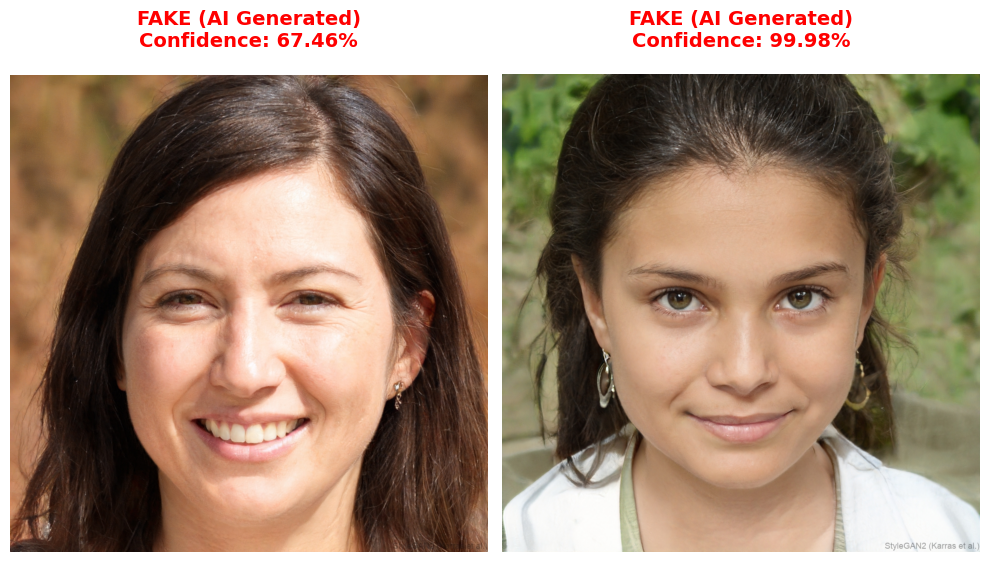

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io
import numpy as np

# --- CONFIGURATION ---
# Ensure we use the same device (GPU/CPU) as the setup code
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def demo_prediction(model, image_bytes):
    """
    Takes raw image bytes, preprocesses them, and runs the AI model.
    Returns: The image object, the label (REAL/FAKE), confidence score, and color.
    """
    # 1. Standard Preprocessing (Must match training!)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # 2. Prepare Image
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    tensor_img = transform(image).unsqueeze(0).to(DEVICE)

    # 3. Run Inference
    model.eval() # Set model to evaluation mode (crucial!)
    with torch.no_grad():
        output = model(tensor_img)
        probability = torch.sigmoid(output).item()

    # 4. Interpret Result (Threshold = 50%)
    if probability > 0.5:
        label = "FAKE (AI Generated)"
        confidence = probability * 100
        color = 'red'  # Red for danger/fake
    else:
        label = "REAL (Human)"
        confidence = (1 - probability) * 100
        color = 'green' # Green for safe/real

    return image, label, confidence, color

# --- MAIN DEMO LOOP ---
print("\n--- 🎓 TEACHER DEMO MODE ---")
print("Upload images to test the model in real-time.")
print("Tip: Use images the model has NEVER seen before.")

uploaded = files.upload()

if len(uploaded) > 0:
    # Setup the display grid
    num_images = len(uploaded)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 6))
    if num_images == 1: axes = [axes] # Handle single image case

    for i, (img_name, img_bytes) in enumerate(uploaded.items()):
        # Get Prediction
        img, label, conf, color = demo_prediction(model, img_bytes)

        # Display
        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')

        # Add Professional Title
        title_text = f"{label}\nConfidence: {conf:.2f}%"
        ax.set_title(title_text, color=color, fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()
else:
    print("No images uploaded.")